
## Business Problem
Hotel Haven wants to predict whether a customer booking will be canceled or not. 
High cancellation rates lead to lost revenue and poor resource planning.

## Project Objective
Build a machine learning model that predicts booking status and identify the factors that influence cancellations.

## Target Variable
booking status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("booking - booking.csv")
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [3]:
df.shape

(36285, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [5]:
df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

In [6]:
df.describe(include="all")

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
count,36285,36285.000000,36285.000000,36285.000000,36285.000000,36285,36285.000000,36285,36285.000000,36285,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285,36285
unique,36285,NaN,NaN,NaN,NaN,4,NaN,7,NaN,5,NaN,NaN,NaN,NaN,NaN,553,2
top,INN36286,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,Online,NaN,NaN,NaN,NaN,NaN,10/13/2018,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27842,NaN,28138,NaN,23221,NaN,NaN,NaN,NaN,NaN,254,24396
mean,NaN,1.844839,0.105360,0.810693,2.204602,NaN,0.030977,NaN,85.239851,NaN,0.025630,0.023343,0.153369,103.421636,0.619733,NaN,NaN
std,NaN,0.518813,0.402704,0.870590,1.410946,NaN,0.173258,NaN,85.938796,NaN,0.158032,0.368281,1.753931,35.086469,0.786262,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,NaN,0.000000,0.000000,0.000000,80.300000,0.000000,NaN,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,NaN,0.000000,0.000000,0.000000,99.450000,0.000000,NaN,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,NaN,0.000000,0.000000,0.000000,120.000000,1.000000,NaN,NaN


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns = (df.columns
      .str.strip()
              
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.columns

Index(['Booking_ID', 'number_of_adults', 'number_of_children',
       'number_of_weekend_nights', 'number_of_week_nights', 'type_of_meal',
       'car_parking_space', 'room_type', 'lead_time', 'market_segment_type',
       'repeated', 'P_C', 'P_not_C', 'average_price', 'special_requests',
       'date_of_reservation', 'booking_status'],
      dtype='object')

### What I found from loading the data

- The dataset has 36,285 bookings and 17 columns
- There are NO missing values — the data is clean
- 67% of bookings were NOT canceled, 33% were canceled
- This means roughly 1 in 3 bookings gets canceled
- The date of reservation column needs to be fixed (stored as text)
- Some bookings show $0 price — these may be complimentary stays

## Data Cleaning

In [9]:
df = df.drop('Booking_ID', axis=1)

print("Booking_ID removed!")
print(f"Columns remaining: {df.shape[1]}")

Booking_ID removed!
Columns remaining: 16


In [10]:
# dropped booking id
if 'Booking_id' in df.columns:
    df = df.drop('Booking_id', axis=1)
    print("Booking_id removed!")
else:
    print("Booking_id column not found in DataFrame")

print(f"Columns remaining: {df.shape[1]}")

Booking_id column not found in DataFrame
Columns remaining: 16


In [11]:
# First, let's check the actual column names in the DataFrame
print("Column names in the DataFrame:", df.columns.tolist())
df['date_of_reservation'] = pd.to_datetime(df['date_of_reservation'], errors='coerce')
print("Number of invalid dates:", df['date_of_reservation'].isna().sum())

# Now pull out useful parts from the date
df['reservation_month'] = df['date_of_reservation'].dt.month
df['reservation_year'] = df['date_of_reservation'].dt.year
df['reservation_day'] = df['date_of_reservation'].dt.dayofweek

# Now drop the original date column
df = df.drop('date_of_reservation', axis=1)

df[['reservation_month', 'reservation_year', 'reservation_day']].head()

Column names in the DataFrame: ['number_of_adults', 'number_of_children', 'number_of_weekend_nights', 'number_of_week_nights', 'type_of_meal', 'car_parking_space', 'room_type', 'lead_time', 'market_segment_type', 'repeated', 'P_C', 'P_not_C', 'average_price', 'special_requests', 'date_of_reservation', 'booking_status']
Number of invalid dates: 37


,reservation_month,reservation_year,reservation_day
0,10.0,2015.0,4.0
1,11.0,2018.0,1.0
2,2.0,2018.0,2.0
3,5.0,2017.0,5.0
4,4.0,2018.0,2.0


In [12]:
# Remove rows where date could not be converted
df = df.dropna(subset=['reservation_month', 'reservation_year', 'reservation_day'])

print(f"Rows removed: 37")
print(f"Rows remaining: {df.shape[0]}")

Rows removed: 37
Rows remaining: 36248


In [13]:
print(f"Final dataset shape: {df.shape}")
print(df.isnull().sum())

Final dataset shape: (36248, 18)
number_of_adults            0
number_of_children          0
number_of_weekend_nights    0
number_of_week_nights       0
type_of_meal                0
car_parking_space           0
room_type                   0
lead_time                   0
market_segment_type         0
repeated                    0
P_C                         0
P_not_C                     0
average_price               0
special_requests            0
booking_status              0
reservation_month           0
reservation_year            0
reservation_day             0
dtype: int64


### Cleaning Summary

- Removed Booking_ID — not useful for prediction
- Fixed date column — extracted month, year and day of week
- Removed 37 rows with invalid dates
- Zero missing values remaining
- Dataset is clean and ready for analysis

## Exploratory Data Analysis (EDA)



In [14]:
print(df.columns.tolist())

['number_of_adults', 'number_of_children', 'number_of_weekend_nights', 'number_of_week_nights', 'type_of_meal', 'car_parking_space', 'room_type', 'lead_time', 'market_segment_type', 'repeated', 'P_C', 'P_not_C', 'average_price', 'special_requests', 'booking_status', 'reservation_month', 'reservation_year', 'reservation_day']


C:\Users\HP\AppData\Local\Temp\ipykernel_26800\4172090660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='booking_status',


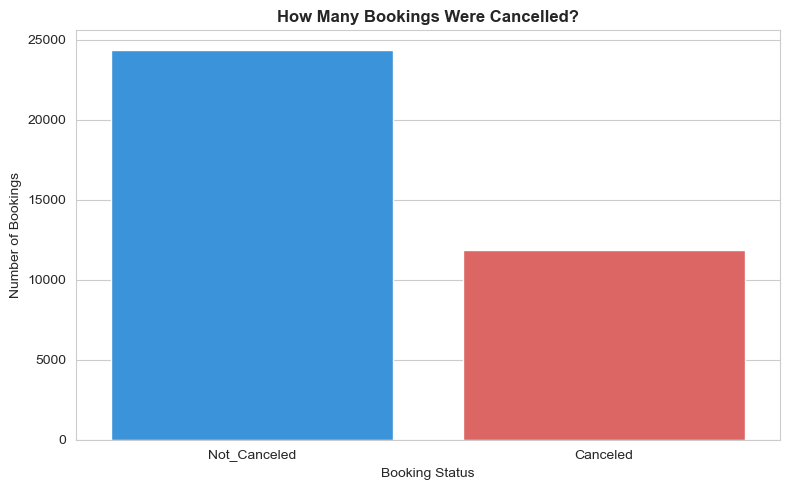

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='booking_status',
                   palette=['#2196F3', '#EF5350'])

plt.title('How Many Bookings Were Cancelled?', fontweight='bold')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.savefig('chart1_cancellation_count.png', dpi=150)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_26800\2809587636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_status', y='lead_time',


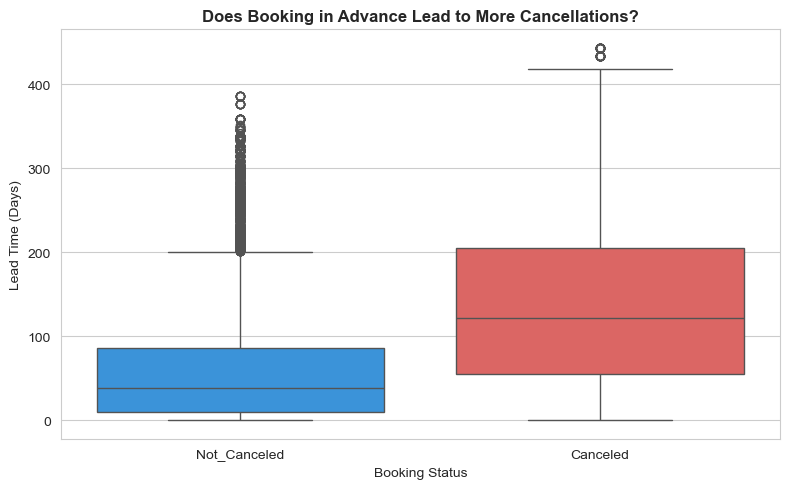

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='booking_status', y='lead_time',
            palette=['#2196F3', '#EF5350'])

plt.title('Does Booking in Advance Lead to More Cancellations?',
          fontweight='bold')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (Days)')

plt.tight_layout()
plt.savefig('chart2_leadtime.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_26800\97769851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_status', y='average_price',


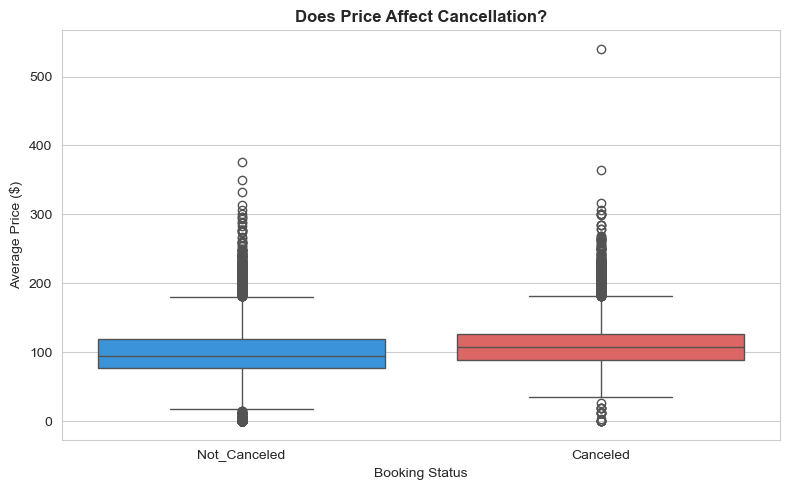

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='booking_status', y='average_price',
            palette=['#2196F3', '#EF5350'])

plt.title('Does Price Affect Cancellation?', fontweight='bold')
plt.xlabel('Booking Status')
plt.ylabel('Average Price ($)')

plt.tight_layout()
plt.savefig('chart3_price.png', dpi=150)
plt.show()

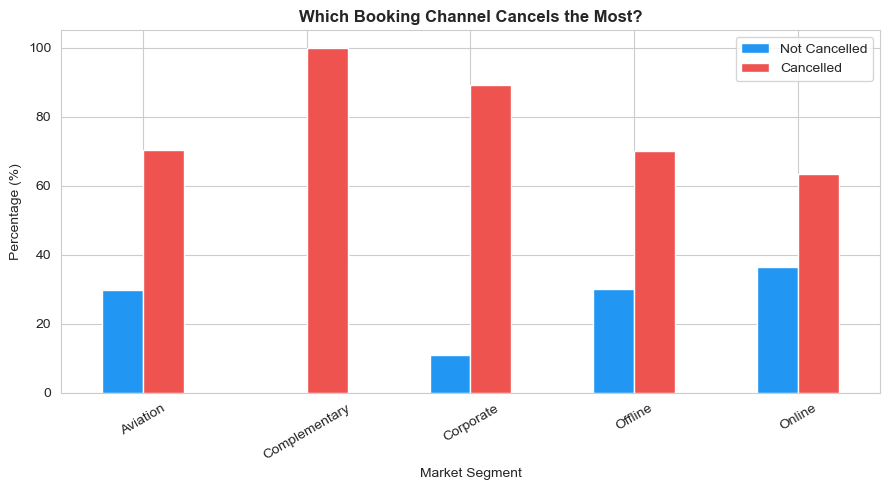

In [18]:
ct = pd.crosstab(df['market_segment_type'], df['booking_status'],
                 normalize='index') * 100

ct.plot(kind='bar', color=['#2196F3', '#EF5350'],
        edgecolor='white', figsize=(9, 5))

plt.title('Which Booking Channel Cancels the Most?', fontweight='bold')
plt.xlabel('Market Segment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.legend(['Not Cancelled', 'Cancelled'])

plt.tight_layout()
plt.savefig('chart4_market_segment.png', dpi=150)
plt.show()

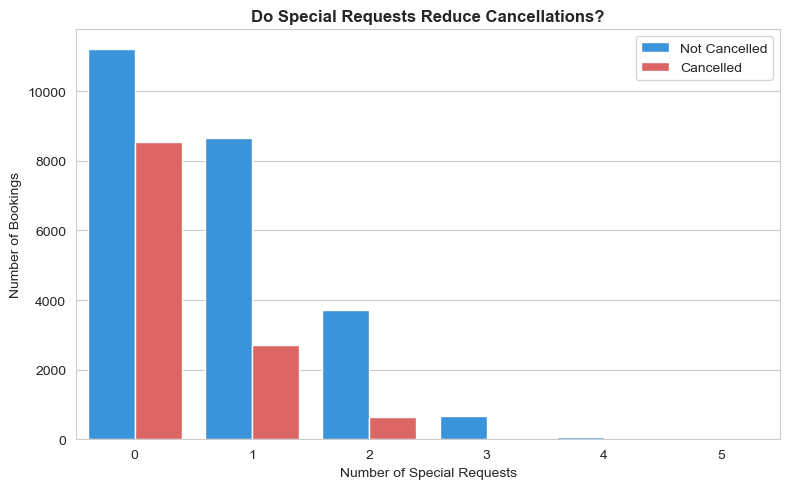

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='special_requests', 
              hue='booking_status',
              palette=['#2196F3', '#EF5350'])

plt.title('Do Special Requests Reduce Cancellations?', 
          fontweight='bold')
plt.xlabel('Number of Special Requests')
plt.ylabel('Number of Bookings')
plt.legend(['Not Cancelled', 'Cancelled'])

plt.tight_layout()
plt.savefig('chart5_special_requests.png', dpi=150)
plt.show()

<Figure size 1000x500 with 0 Axes>

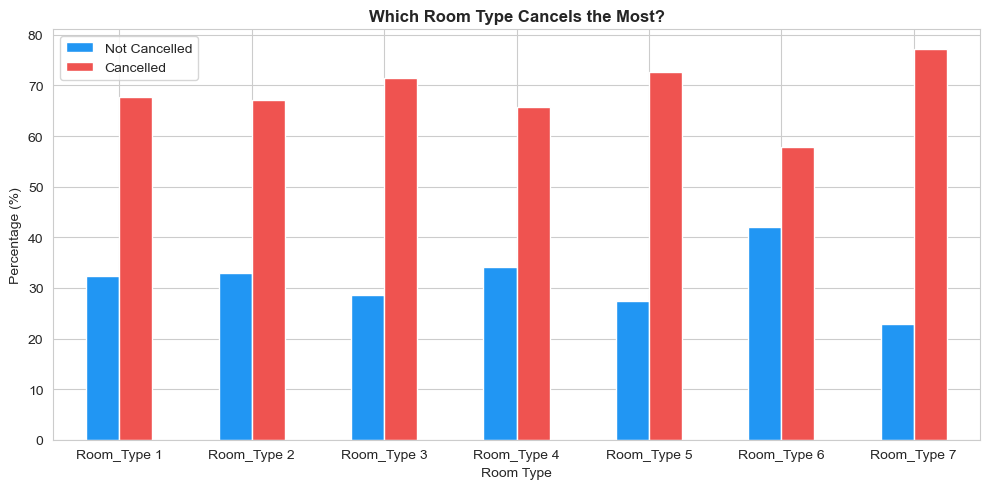

In [20]:
plt.figure(figsize=(10, 5))

ct = pd.crosstab(df['room_type'], df['booking_status'],
                 normalize='index') * 100

ct.plot(kind='bar', color=['#2196F3', '#EF5350'],
        edgecolor='white', figsize=(10, 5))

plt.title('Which Room Type Cancels the Most?', fontweight='bold')
plt.xlabel('Room Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['Not Cancelled', 'Cancelled'])

plt.tight_layout()
plt.savefig('chart6_room_type.png', dpi=150)
plt.show()

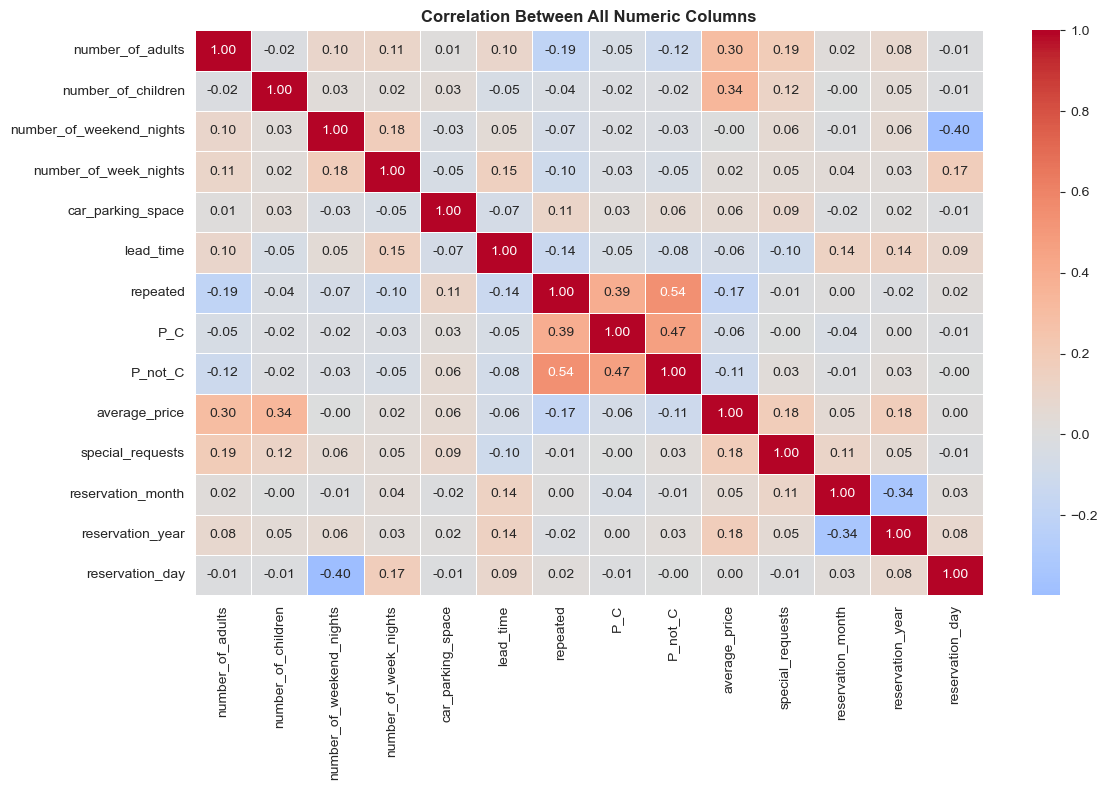

In [21]:
plt.figure(figsize=(12, 8))

# Only use numeric columns
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Correlation Between All Numeric Columns', 
          fontweight='bold')

plt.tight_layout()
plt.savefig('chart7_correlation.png', dpi=150)
plt.show()

## Feature Engineering

In [22]:
# Total nights stayed
df['total_nights'] = df['number_of_weekend_nights'] + df['number_of_week_nights']

# Total guests
df['total_guests'] = df['number_of_adults'] + df['number_of_children']

# Price per night
df['price_per_night'] = df['average_price'] / (df['total_nights'] + 1)

print("New features created!")
print(df[['total_nights', 'total_guests', 'price_per_night']].head())

New features created!
   total_nights  total_guests  price_per_night
0             7             2        11.000000
1             4             1        21.336000
2             4             3        10.000000
3             2             1        33.333333
4             3             1        19.250000


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns
df['type_of_meal'] = le.fit_transform(df['type_of_meal'])
df['room_type'] = le.fit_transform(df['room_type'])
df['market_segment_type'] = le.fit_transform(df['market_segment_type'])

# Encode target column
df['booking_status'] = le.fit_transform(df['booking_status'])

# print("Encoding done!")
# print("\nBooking status values:", df['booking_status'].unique())
# print(df.head())

In [24]:
from sklearn.model_selection import train_test_split

# X = everything we use to predict
# y = what we are predicting
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")
print(f"\nX columns: {X.shape[1]}")

Training rows: 28998
Testing rows:  7250

X columns: 20


In [25]:
# First, install xgboost if you're in a notebook environment
!pip install xgboost

# Then run your corrected code
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Assuming X_train and X_test are pandas DataFrames
# First, identify categorical columns (those with string values)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a preprocessor that will handle both numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_processed, y_train)
print("Logistic Regression trained!")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)
print("Random Forest trained!")

# Model 3: XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_processed, y_train)
print("XGBoost trained!")

print("\nAll 3 models trained successfully!")

Logistic Regression trained!
Random Forest trained!
XGBoost trained!

All 3 models trained successfully!


## Model Evaluation

In [26]:
# Check what columns are still in X
print(X.columns.tolist())

['number_of_adults', 'number_of_children', 'number_of_weekend_nights', 'number_of_week_nights', 'type_of_meal', 'car_parking_space', 'room_type', 'lead_time', 'market_segment_type', 'repeated', 'P_C', 'P_not_C', 'average_price', 'special_requests', 'reservation_month', 'reservation_year', 'reservation_day', 'total_nights', 'total_guests', 'price_per_night']


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaler done! X_test_sc is ready.")

Scaler done! X_test_sc is ready.


In [28]:
from sklearn.metrics import accuracy_score, classification_report

models = {
    'Logistic Regression': (lr, X_test_sc),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb, X_test)
}

for name, (model, X_t) in models.items():
    preds = model.predict(X_t)
    acc = accuracy_score(y_test, preds)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"  Accuracy: {acc*100:.2f}%")
    print(f"{'='*45}")
    print(classification_report(y_test, preds,
          target_names=['Not Cancelled', 'Cancelled']))


  Logistic Regression
  Accuracy: 80.47%
               precision    recall  f1-score   support

Not Cancelled       0.75      0.60      0.67      2369
    Cancelled       0.82      0.90      0.86      4881

     accuracy                           0.80      7250
    macro avg       0.79      0.75      0.77      7250
 weighted avg       0.80      0.80      0.80      7250


  Random Forest
  Accuracy: 37.41%
               precision    recall  f1-score   support

Not Cancelled       0.34      0.99      0.51      2369
    Cancelled       0.96      0.07      0.14      4881

     accuracy                           0.37      7250
    macro avg       0.65      0.53      0.32      7250
 weighted avg       0.76      0.37      0.26      7250



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



  XGBoost
  Accuracy: 39.92%
               precision    recall  f1-score   support

Not Cancelled       0.28      0.55      0.38      2369
    Cancelled       0.60      0.32      0.42      4881

     accuracy                           0.40      7250
    macro avg       0.44      0.44      0.40      7250
 weighted avg       0.50      0.40      0.41      7250



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


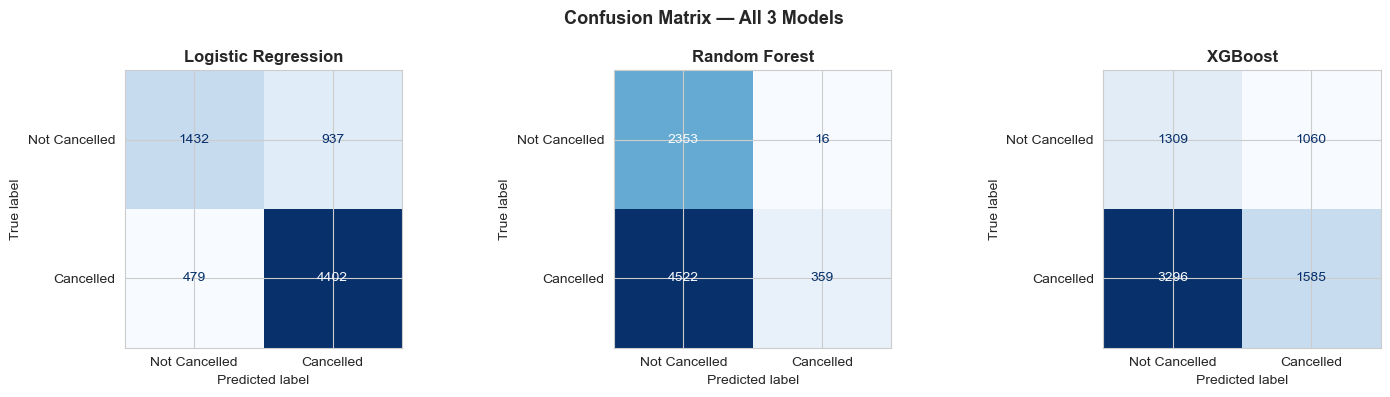

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (model, X_t)) in zip(axes, models.items()):
    preds = model.predict(X_t)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, 
           display_labels=['Not Cancelled', 'Cancelled'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrix — All 3 Models', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


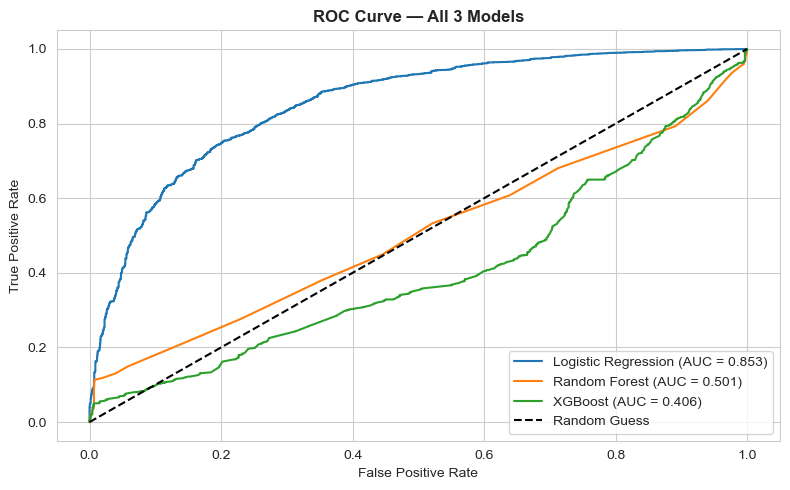

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 5))

for name, (model, X_t) in models.items():
    probs = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 3 Models', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

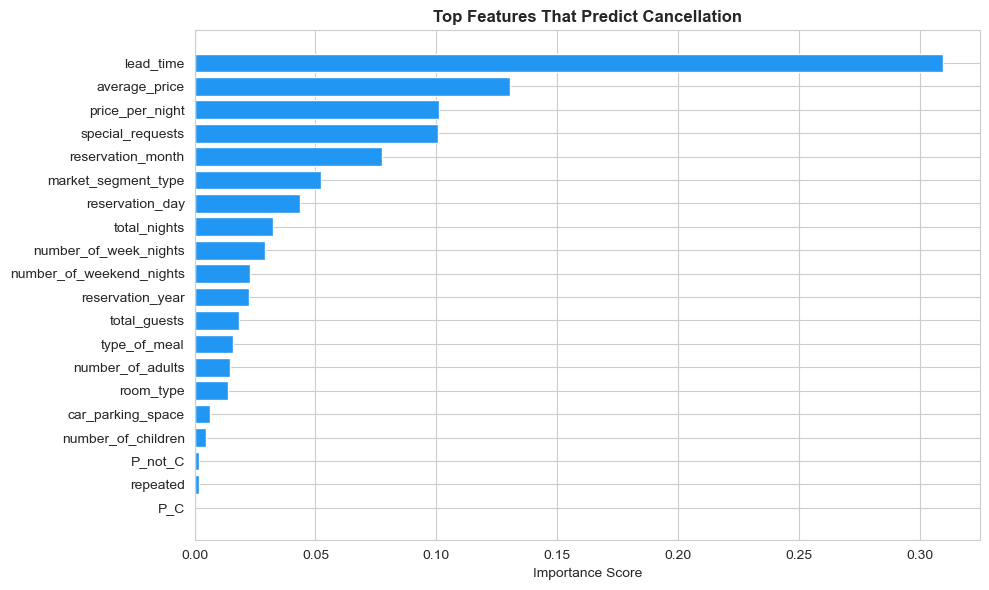

In [31]:
import numpy as np

plt.figure(figsize=(10, 6))

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.barh(range(len(indices)), importances[indices],
         color='#2196F3', edgecolor='white')
plt.yticks(range(len(indices)), 
           [features[i] for i in indices])
plt.xlabel('Importance Score')
plt.title('Top Features That Predict Cancellation', 
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()